# Sequence Model Comparison for Prot Regression

This notebook compares three machine-learning routes on the same Kepler split:
- `LightPred` (`LSTM + Transformer`)
- `CNN`
- `LSTM`

It is intended for Chapter 4 figures and tables.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlepad'] = 10
plt.rcParams['grid.alpha'] = 0.18
plt.rcParams['grid.linestyle'] = ':'

ROOT = Path('.')
MODEL_FILES = {
    'LightPred': {
        'summary': ROOT / 'data/kepler/models/lightpred_eval_summary.csv',
        'pred': ROOT / 'data/kepler/models/lightpred_predictions.csv',
        'log': ROOT / 'data/kepler/models/lightpred_train_log.csv',
    },
    'CNN': {
        'summary': ROOT / 'data/kepler/models/cnn/cnn_eval_summary.csv',
        'pred': ROOT / 'data/kepler/models/cnn/cnn_predictions.csv',
        'log': ROOT / 'data/kepler/models/cnn/cnn_train_log.csv',
    },
    'LSTM': {
        'summary': ROOT / 'data/kepler/models/lstm/lstm_eval_summary.csv',
        'pred': ROOT / 'data/kepler/models/lstm/lstm_predictions.csv',
        'log': ROOT / 'data/kepler/models/lstm/lstm_train_log.csv',
    },
}
BASELINE_CMP = ROOT / 'data/kepler/models/cnn/cnn_baseline_compare_val.csv'
PALETTE = {
    'LightPred': '#4C72B0',
    'CNN': '#55A868',
    'LSTM': '#C44E52',
    'QP-GP': '#8172B2',
    'GPS': '#CCB974',
    'LS': '#64B5CD',
    'ACF': '#8C8C8C',
}

In [2]:
model_summaries = []
model_preds = {}
model_logs = {}
for model_name, paths in MODEL_FILES.items():
    for key, path in paths.items():
        if not path.exists():
            raise FileNotFoundError(path)
    df_summary = pd.read_csv(paths['summary'])
    df_pred = pd.read_csv(paths['pred'])
    df_log = pd.read_csv(paths['log'])
    df_summary['model'] = model_name
    model_summaries.append(df_summary)
    model_preds[model_name] = df_pred
    model_logs[model_name] = df_log

summary_all = pd.concat(model_summaries, ignore_index=True)
summary_val = summary_all[summary_all['subset'] == 'val'].copy()
baseline_df = pd.read_csv(BASELINE_CMP)
baseline_df['method'] = baseline_df['method'].replace({'cnn': 'CNN'})

summary_val.sort_values('MAE')

,subset,N,MAE,RMSE,MedianAbsErr,Bias,MedianBias,Frac(<10%),Frac(<20%),model
5,val,90,6.232946,8.270755,4.181109,-0.850115,0.124796,0.255556,0.422222,CNN
8,val,90,8.441715,10.334908,7.475070,-0.290691,-0.365362,0.166667,0.344444,LSTM
2,val,90,9.317822,11.135739,8.390635,-3.686170,-3.507852,0.100000,0.177778,LightPred


## Validation Summary Table

In [3]:
cols = ['model', 'N', 'MAE', 'RMSE', 'MedianAbsErr', 'Bias', 'MedianBias', 'Frac(<10%)', 'Frac(<20%)']
display(summary_val[cols].sort_values('MAE').round(4).reset_index(drop=True))

,model,N,MAE,RMSE,MedianAbsErr,Bias,MedianBias,Frac(<10%),Frac(<20%)
0,CNN,90,6.2329,8.2708,4.1811,-0.8501,0.1248,0.2556,0.4222
1,LSTM,90,8.4417,10.3349,7.4751,-0.2907,-0.3654,0.1667,0.3444
2,LightPred,90,9.3178,11.1357,8.3906,-3.6862,-3.5079,0.1000,0.1778


## Validation Metric Comparison

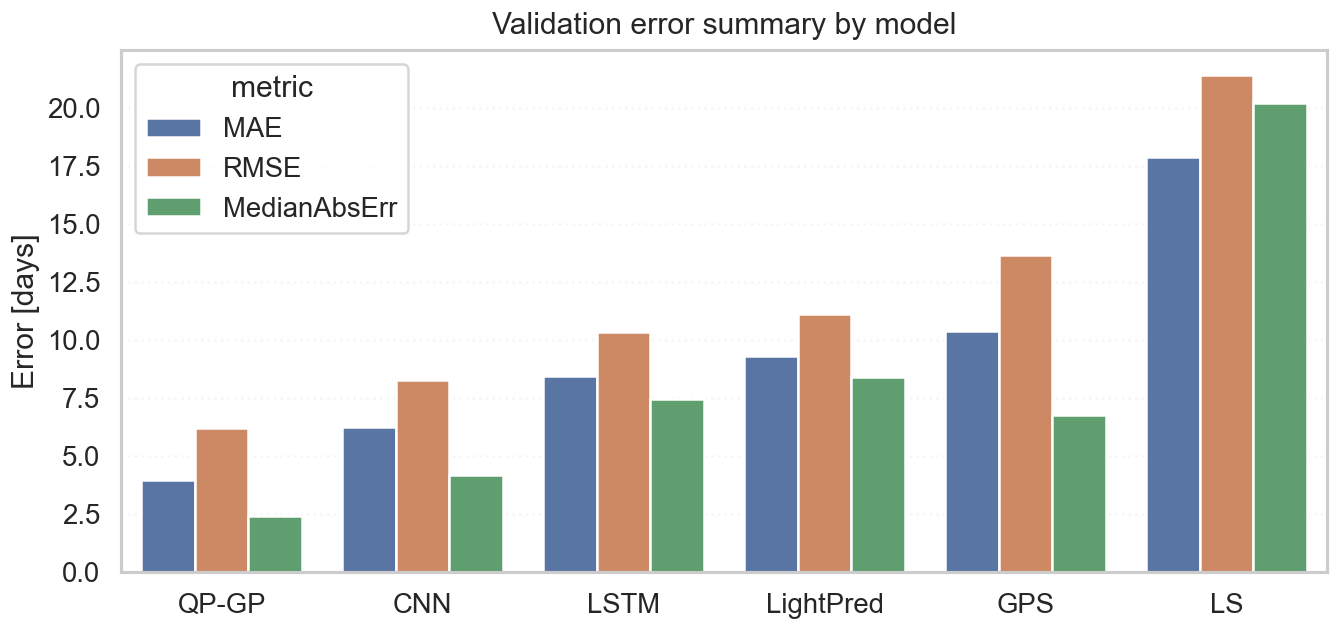

In [4]:
metric_cols = ['MAE', 'RMSE', 'MedianAbsErr']
plot_df = summary_val[['model'] + metric_cols].melt(id_vars='model', var_name='metric', value_name='value')
reference = baseline_df[baseline_df['method'].isin(['QP-GP', 'GPS', 'LS'])][['method'] + metric_cols].rename(columns={'method': 'model'})
plot_df = pd.concat([
    plot_df,
    reference.melt(id_vars='model', var_name='metric', value_name='value')
], ignore_index=True)
order = plot_df.groupby('model')['value'].mean().sort_values().index
fig, ax = plt.subplots(figsize=(11.5, 5.6))
sns.barplot(data=plot_df, x='model', y='value', hue='metric', order=order, ax=ax)
ax.set_title('Validation error summary by model')
ax.set_xlabel('')
ax.set_ylabel('Error [days]')
plt.tight_layout()
plt.show()

## Label vs Prediction

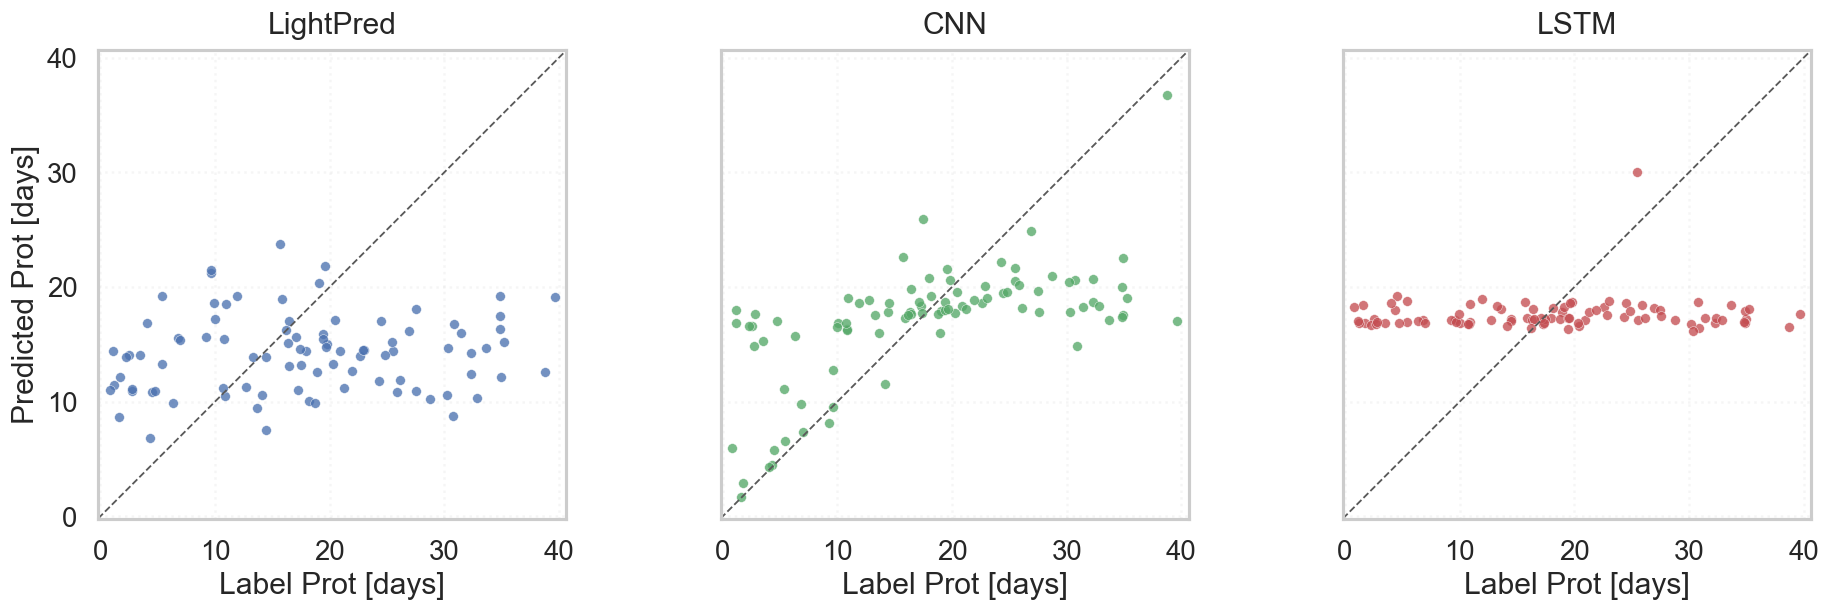

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2), sharex=True, sharey=True)
for ax, model_name in zip(axes, ['LightPred', 'CNN', 'LSTM']):
    df = model_preds[model_name]
    df = df[df['split'] == 'val'].copy()
    sns.scatterplot(
        data=df,
        x='true_period',
        y='pred_period',
        s=34,
        alpha=0.78,
        edgecolor='white',
        linewidth=0.3,
        color=PALETTE[model_name],
        ax=ax,
    )
    lim_min = min(df['true_period'].min(), df['pred_period'].min())
    lim_max = max(df['true_period'].max(), df['pred_period'].max())
    lims = [lim_min - 1, lim_max + 1]
    ax.plot(lims, lims, linestyle='--', color='0.35', linewidth=1.1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(model_name)
    ax.set_xlabel('Label Prot [days]')
    ax.set_ylabel('Predicted Prot [days]')
    ax.set_aspect('equal', 'box')
plt.tight_layout()
plt.show()

## Relative Error ECDF

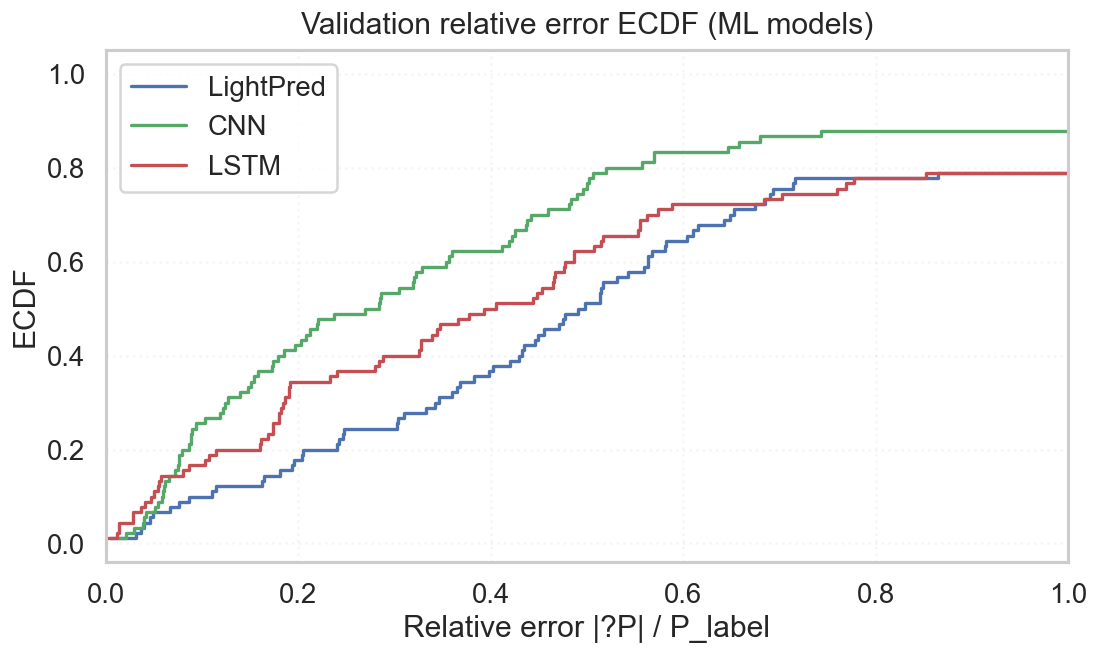

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 5.8))
for model_name in ['LightPred', 'CNN', 'LSTM']:
    df = model_preds[model_name]
    rel = df.loc[df['split'] == 'val', 'rel_err'].dropna().sort_values().to_numpy()
    y = np.arange(1, len(rel) + 1) / len(rel)
    ax.step(rel, y, where='post', linewidth=2.0, label=model_name, color=PALETTE[model_name])

for method in ['QP-GP', 'GPS', 'LS']:
    row = baseline_df[baseline_df['method'] == method]
    # rebuild ECDF from shared validation split using the exported compare table is not possible,
    # so keep the main ML comparison here and add baseline hit-rate in the next figure.

ax.set_xlim(0, 1.0)
ax.set_xlabel('Relative error |?P| / P_label')
ax.set_ylabel('ECDF')
ax.set_title('Validation relative error ECDF (ML models)')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## Hit Rate and Baseline Reference

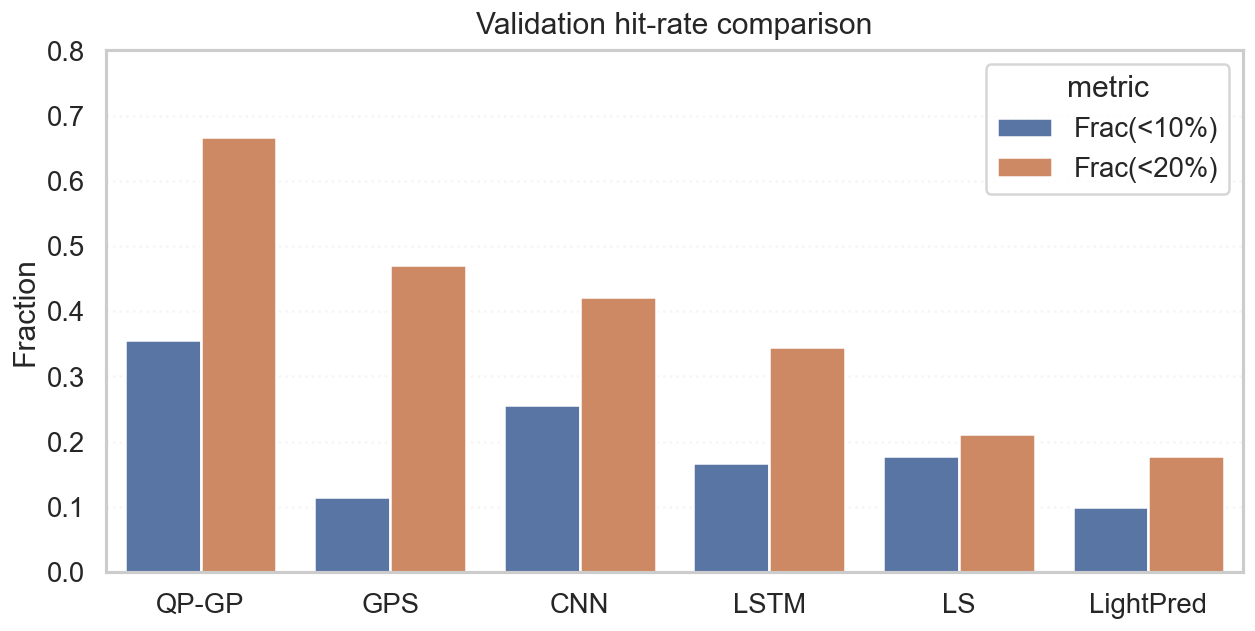

In [7]:
ml_hit = summary_val[['model', 'Frac(<10%)', 'Frac(<20%)']].copy()
ref_hit = baseline_df[baseline_df['method'].isin(['QP-GP', 'GPS', 'LS'])][['method', 'Frac(<10%)', 'Frac(<20%)']].rename(columns={'method': 'model'})
hit_df = pd.concat([ml_hit, ref_hit], ignore_index=True)
plot_df = hit_df.melt(id_vars='model', var_name='metric', value_name='value')
order = hit_df.sort_values('Frac(<20%)', ascending=False)['model']
fig, ax = plt.subplots(figsize=(10.8, 5.6))
sns.barplot(data=plot_df, x='model', y='value', hue='metric', order=order, ax=ax)
ax.set_title('Validation hit-rate comparison')
ax.set_xlabel('')
ax.set_ylabel('Fraction')
ax.set_ylim(0, 0.8)
plt.tight_layout()
plt.show()

## Validation MAE During Training

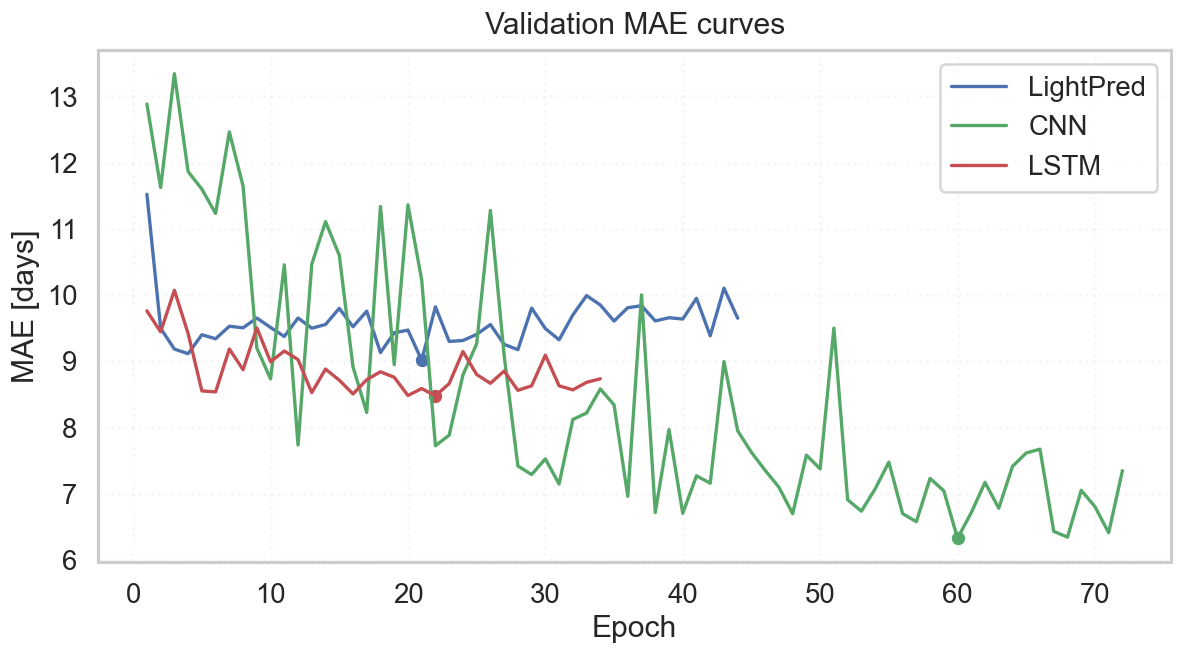

In [8]:
fig, ax = plt.subplots(figsize=(10.2, 5.8))
for model_name in ['LightPred', 'CNN', 'LSTM']:
    df = model_logs[model_name].copy()
    ax.plot(df['epoch'], df['val_mae'], label=model_name, linewidth=2.0, color=PALETTE[model_name])
    best_idx = df['val_mae'].idxmin()
    ax.scatter(df.loc[best_idx, 'epoch'], df.loc[best_idx, 'val_mae'], color=PALETTE[model_name], s=42)
ax.set_title('Validation MAE curves')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE [days]')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## Error by Period Bin

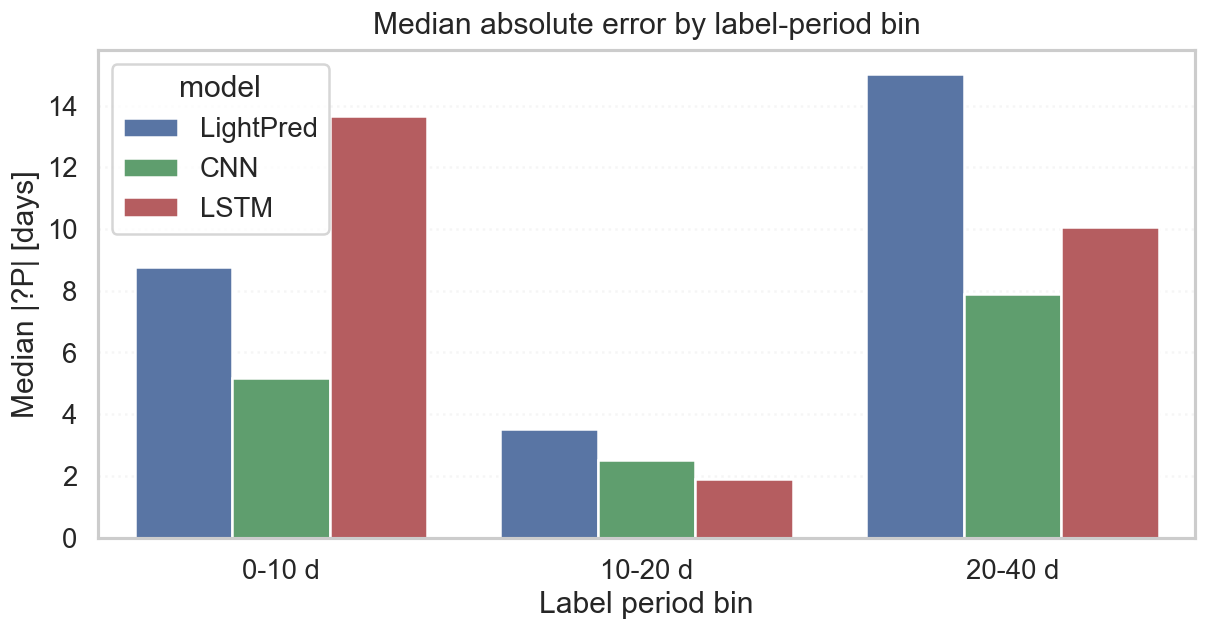

model,CNN,LSTM,LightPred
period_bin,,,
0-10 d,5.1735,13.6737,8.7722
10-20 d,2.4968,1.8916,3.5079
20-40 d,7.8773,10.0770,15.0349


In [9]:
rows = []
bins = [0, 10, 20, 40.1]
labels = ['0-10 d', '10-20 d', '20-40 d']
for model_name in ['LightPred', 'CNN', 'LSTM']:
    df = model_preds[model_name]
    df = df[df['split'] == 'val'].copy()
    df['period_bin'] = pd.cut(df['true_period'], bins=bins, labels=labels, include_lowest=True, right=False)
    grouped = df.groupby('period_bin', observed=False)['abs_err'].median().reset_index()
    grouped['model'] = model_name
    rows.append(grouped)
period_bin_df = pd.concat(rows, ignore_index=True)
fig, ax = plt.subplots(figsize=(10.4, 5.6))
sns.barplot(data=period_bin_df, x='period_bin', y='abs_err', hue='model', palette=PALETTE, ax=ax)
ax.set_title('Median absolute error by label-period bin')
ax.set_xlabel('Label period bin')
ax.set_ylabel('Median |?P| [days]')
plt.tight_layout()
plt.show()

display(period_bin_df.pivot(index='period_bin', columns='model', values='abs_err').round(4))